# 2213645 刘嘉硕 回归分析上机作业1

## (1) 检查复共线性

In [1]:
# 加载数据集
data(longley)
longley <- as.data.frame(longley)
longley

,GNP.deflator,GNP,Unemployed,Armed.Forces,Population,Year,Employed
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1947,83.0,234.289,235.6,159.0,107.608,1947,60.323
1948,88.5,259.426,232.5,145.6,108.632,1948,61.122
1949,88.2,258.054,368.2,161.6,109.773,1949,60.171
1950,89.5,284.599,335.1,165.0,110.929,1950,61.187
1951,96.2,328.975,209.9,309.9,112.075,1951,63.221
1952,98.1,346.999,193.2,359.4,113.270,1952,63.639
1953,99.0,365.385,187.0,354.7,115.094,1953,64.989
1954,100.0,363.112,357.8,335.0,116.219,1954,63.761
1955,101.2,397.469,290.4,304.8,117.388,1955,66.019


In [3]:
longley_scaled <- scale(longley[, -which(names(longley) == "Employed")])
X <- model.matrix(Employed ~ ., data = data.frame(Employed = longley$Employed, longley_scaled))
X

,(Intercept),GNP.deflator,GNP,Unemployed,Armed.Forces,Population,Year
1947,1,-1.73109925,-1.5434331,-0.8960348,-1.46092666,-1.411135233,-1.5753151
1948,1,-1.22144139,-1.2905329,-0.9292089,-1.65347763,-1.263926342,-1.3652731
1949,1,-1.24924091,-1.3043364,0.5229601,-1.42356602,-1.099897684,-1.1552311
1950,1,-1.12877633,-1.0372705,0.1687464,-1.37470980,-0.933712647,-0.9451891
1951,1,-0.50792039,-0.5908091,-1.1710587,0.70742726,-0.768965196,-0.7351470
1952,1,-0.33185676,-0.4094719,-1.3497707,1.41871632,-0.597173570,-0.5251050
1953,1,-0.24845821,-0.2244927,-1.4161189,1.35117978,-0.334957732,-0.3150630
1954,1,-0.15579314,-0.2473611,0.4116664,1.06810111,-0.173229213,-0.1050210
1955,1,-0.04459506,0.0983004,-0.3096025,0.63414293,-0.005175313,0.1050210
1956,1,0.27046616,0.3167321,-0.3973534,0.35968594,0.188323875,0.3150630


In [12]:
longley <- data.frame(longley_scaled,Employed = longley$Employed)
longley#将前六列标准化后的longley

,GNP.deflator,GNP,Unemployed,Armed.Forces,Population,Year,Employed
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1947,-1.73109925,-1.5434331,-0.8960348,-1.46092666,-1.411135233,-1.5753151,60.323
1948,-1.22144139,-1.2905329,-0.9292089,-1.65347763,-1.263926342,-1.3652731,61.122
1949,-1.24924091,-1.3043364,0.5229601,-1.42356602,-1.099897684,-1.1552311,60.171
1950,-1.12877633,-1.0372705,0.1687464,-1.37470980,-0.933712647,-0.9451891,61.187
1951,-0.50792039,-0.5908091,-1.1710587,0.70742726,-0.768965196,-0.7351470,63.221
1952,-0.33185676,-0.4094719,-1.3497707,1.41871632,-0.597173570,-0.5251050,63.639
1953,-0.24845821,-0.2244927,-1.4161189,1.35117978,-0.334957732,-0.3150630,64.989
1954,-0.15579314,-0.2473611,0.4116664,1.06810111,-0.173229213,-0.1050210,63.761
1955,-0.04459506,0.0983004,-0.3096025,0.63414293,-0.005175313,0.1050210,66.019


此后的longley数据集中的前六列都是已经标准化后的

In [5]:
eigen_values <- eigen(t(X) %*% X)$values
max_eigen_value <- max(eigen_values)
min_eigen_value <- min(eigen_values)
k <- max_eigen_value / min_eigen_value #矩阵X'X的条件数
if(k < 100){
    cat('复共线性很小。')
} else if(k >= 100 && k <= 1000){
    cat("复共线性较强。")
} else{
    cat("复共线性严重。")
}

复共线性严重。

## (2) 使用主成分回归解决复共线性，选择适当个数的主成分

In [6]:
pca_results <- prcomp(longley[, -c(7)], scale. = TRUE) # 计算主成分
summary(pca_results)

Importance of components:
                          PC1    PC2    PC3     PC4     PC5     PC6
Standard deviation     2.1455 1.0841 0.4510 0.12218 0.05052 0.01941
Proportion of Variance 0.7672 0.1959 0.0339 0.00249 0.00043 0.00006
Cumulative Proportion  0.7672 0.9631 0.9970 0.99951 0.99994 1.00000

In [7]:
n_components <- 2 # 选择主成分个数，选择累积贡献率达到95%以上的主成分
cat('选择主成分的个数为:', n_components)
pca_scores <- pca_results$x[, 1:n_components]
cat('\n每个观测值在选择的两个主成分上的坐标为：\n')
pca_scores

选择主成分的个数为: 2
每个观测值在选择的两个主成分上的坐标为：


,PC1,PC2
1947,-3.47885116,-0.7514663
1948,-3.01051050,-0.8490405
1949,-2.34330004,-1.5399966
1950,-2.09390207,-1.2763204
1951,-1.43823979,1.2357941
1952,-1.01025833,1.9221044
1953,-0.70242732,1.9105632
1954,0.03249036,0.5930479
1955,0.09951208,0.6934927
1956,0.44943161,0.5478444


In [8]:
pcr_model <- lm(longley$Employed ~ pca_scores)
loadings <- pca_results$rotation[, 1:n_components]
coefficients <- coef(pcr_model)
cat('主成分回归模型系数：\n')
print(coefficients)

主成分回归模型系数：
  (Intercept) pca_scoresPC1 pca_scoresPC2 
   65.3170000     1.5651125     0.3918278 


In [9]:
# 计算原始变量的系数
original_coefficients <- loadings %*% coefficients[2:(n_components + 1)]
original_coefficients <- c(coefficients[1], original_coefficients)
names(original_coefficients) <- c("Intercept", colnames(longley)[-7])  
cat('主成分分析后原始线性模型系数为：\n')
print(original_coefficients)

主成分分析后原始线性模型系数为：
   Intercept GNP.deflator          GNP   Unemployed Armed.Forces   Population 
  65.3170000    0.7454880    0.7431563    0.2695580    0.6281394    0.7056736 
        Year 
   0.7279263 


## (3) 使用岭回归解决复共线性，并采用不同方法估计岭参数

modified HKB estimator is 0.004275357 
modified L-W estimator is 0.03229531 
smallest value of GCV  at 0.0028 


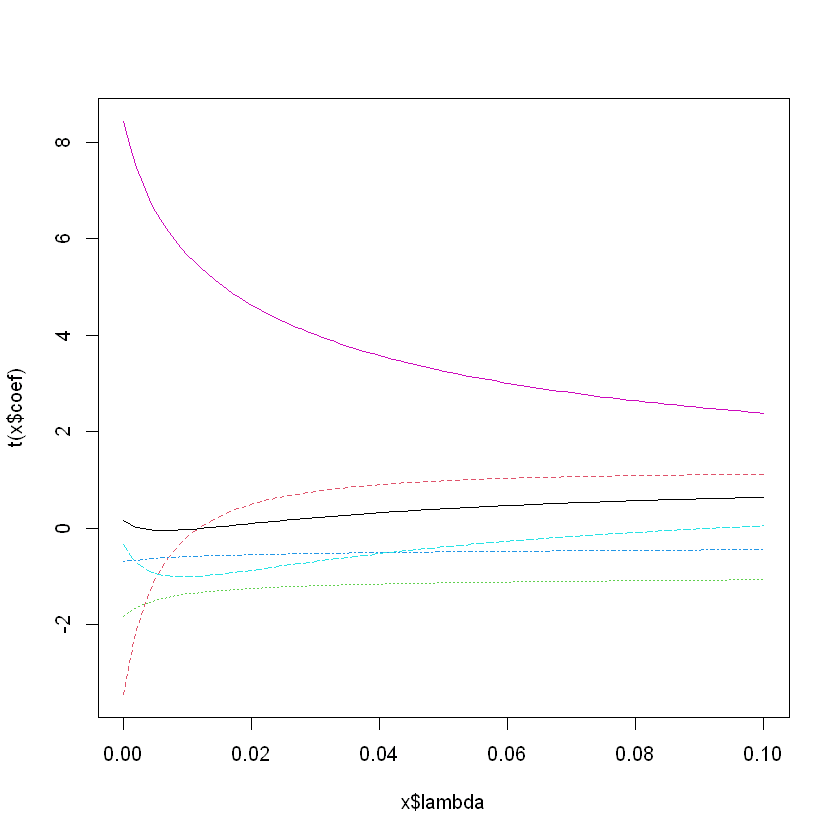

In [10]:
library(MASS)
plot(lm.ridge(longley[,7]~longley[,1]+longley[,2]+longley[,3]+longley[,4]+longley[,5]+longley[,6] ,lambda = seq(0,.1,.001)))
#此处的longley前6列数据已经标准化
select(lm.ridge(longley[,7]~longley[,1]+longley[,2]+longley[,3]+longley[,4]+longley[,5]+longley[,6] ,lambda = seq(0,5,.0001)))

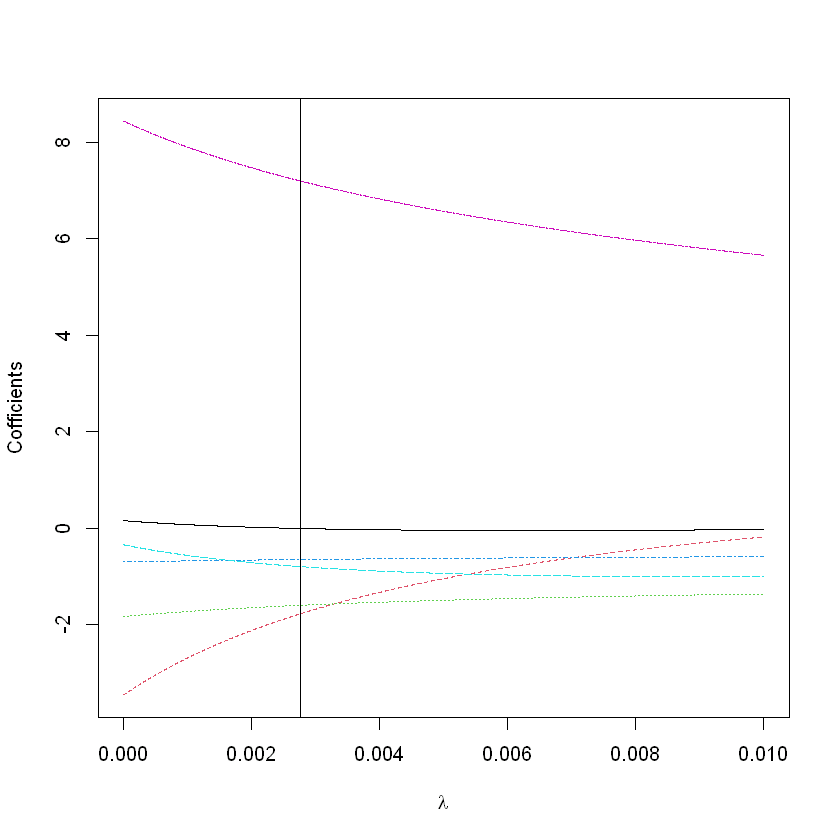

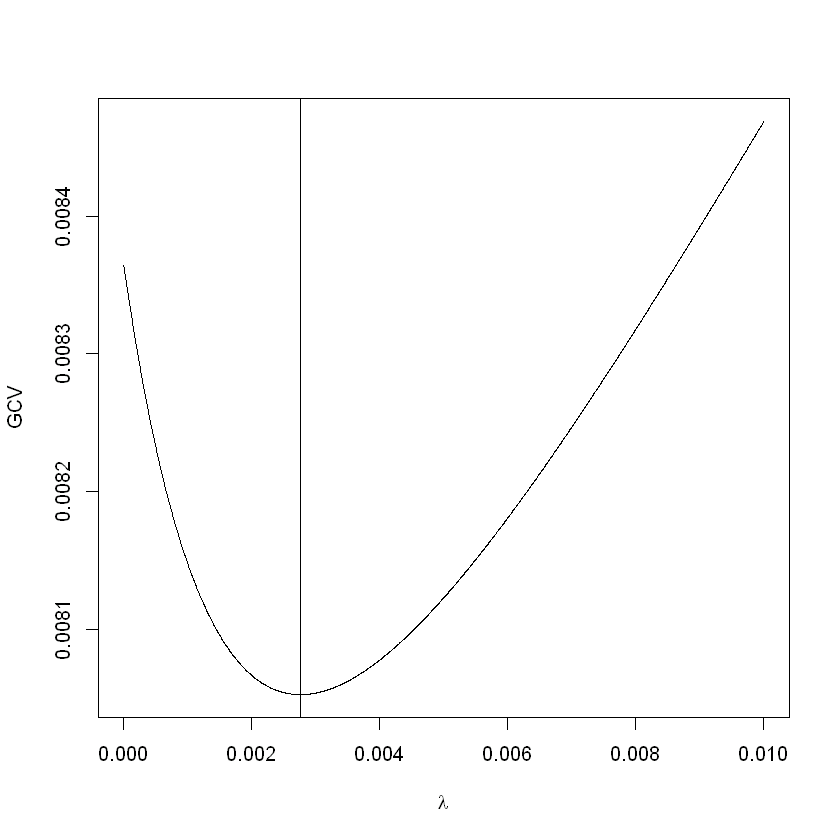

In [11]:
library(MASS)
library(ggplot2)
 
ridge.sol <- lm.ridge(Employed~., lambda = seq(0,0.01, length = 2000), data = longley, model = TRUE) 
matplot(x=ridge.sol$lambda, y=t(ridge.sol$coef), xlab = expression(lambda), ylab= "Cofficients", type = "l", lty = 1:20)
abline(v = ridge.sol$lambda[which.min(ridge.sol$GCV)])#作出lambdaGCV取最小值时的那条竖直线
plot(ridge.sol$lambda, ridge.sol$GCV, type = "l", xlab = expression(lambda), ylab = expression(GCV))
abline(v = ridge.sol$lambda[which.min(ridge.sol$GCV)]) 

选择λ为0.028

估计岭回归参数λ为0.028